In [1]:
!apt-get clean
!apt-get update
!apt-get install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,847 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,877 kB]
Get:

In [2]:
# ==============================================================================
# Anisotropic Womersley Solver
# ------------------------------------------------------------------------------
# This solver is used in the paper: "A transverse piconewton-scale force field
# revealed in anisotropic Womersley flow" by Dr. Khalid Saqr
# The solver runs a complete, two-stage analysis using high-fidelity boundary
# conditions derived from digitized physiological waveforms and a physically
# consistent scaling framework.
# Copyright © Khalid Saqr. All rights reserved.
# ==============================================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogFormatterMathtext
from tqdm import tqdm

# ==============================================================================
# GLOBAL SETTINGS
# ==============================================================================
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,

        # TeX typography (JFM-grade)
        "text.usetex": False, # Changed from True to False to resolve RuntimeError
        "text.latex.preamble": r"""
            \usepackage{amsmath}
            \usepackage{mathptmx}
        """,

        "font.family": "serif",

        # Base font
        "font.size": 16,

        # Axis labels
        "axes.labelsize": 18,
        "axes.titlesize": 18,   # titles unused, keep consistent

        "xtick.labelsize": 15,
        "ytick.labelsize": 15,

        "legend.fontsize": 15,

        "mathtext.fontset": "cm",

        "axes.linewidth": 1.1,
        "lines.linewidth": 2.0,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.35,
    })

def save_fig(fig, stem: str):
    fig.savefig(os.path.join(FIGDIR, f"{stem}.png"))
    fig.savefig(os.path.join(FIGDIR, f"{stem}.pdf"))

def light_grid(ax):
    ax.grid(True, which="major")
    ax.minorticks_on()

def panel_label(ax, label: str):
    ax.text(0.86, 0.96, label, transform=ax.transAxes,
            ha="right", va="top", fontsize=16,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=1))

# ==============================================================================
# CORE SOLVER (Chebyshev spectral discretization)
# ==============================================================================
class WomersleySolver:
    def __init__(self, N: int):
        if N < 60:
            raise ValueError("Use N >= 60 for reasonable accuracy.")
        self.N = N
        self.n = N + 1
        self._setup_discretization()

    def _setup_discretization(self):
        k = np.arange(self.n)
        x = np.cos(np.pi * k / self.N)
        c = np.ones(self.n)
        c[0] = 2.0
        c[-1] = 2.0
        c *= (-1.0) ** k

        X = np.tile(x, (self.n, 1))
        dX = X - X.T + np.eye(self.n)
        D_cheb = (np.outer(c, 1.0 / c)) / dX
        D_cheb -= np.diag(np.sum(D_cheb, axis=1))

        # map x in [-1,1] to r in [0,1]
        self.r = (1.0 - x) / 2.0
        self.D = D_cheb * (-2.0)

        r_safe = self.r.copy()
        r_safe[0] = 1e-12
        invr = sp.diags(1.0 / r_safe)
        invr2 = sp.diags(1.0 / (r_safe ** 2))

        Dsp = sp.csr_matrix(self.D)
        D2sp = sp.csr_matrix(self.D @ self.D)

        self.L0 = D2sp + invr @ Dsp
        self.L1 = self.L0 - invr2

    def solve_harmonic(self, alpha, f_h, a_h, beta, gamma=None, delta=1.0):
        # allow symmetric coupling if gamma not provided
        if gamma is None:
            gamma = beta

        I = sp.eye(self.n, format="csr")
        Azz = (1j * f_h * alpha**2) * I - self.L0
        Azt = -beta * self.L1
        Atz = -gamma * self.L0
        Att = (1j * f_h * alpha**2) * I - delta * self.L1

        b_z = a_h * np.ones(self.n, dtype=complex)
        b_t = np.zeros(self.n, dtype=complex)

        Azzb, Aztb = Azz.tolil(), Azt.tolil()
        Attb, Atzb = Att.tolil(), Atz.tolil()
        bz, bt = b_z.copy(), b_t.copy()

        # BCs:
        # axial: symmetry at center (du/dr=0), no-slip at wall (u=0)
        # swirl: regular at center (u=0), no-slip at wall (u=0)
        Azzb[0, :], Aztb[0, :], bz[0] = self.D[0, :], 0.0, 0.0
        Azzb[-1, :], Azzb[-1, -1], Aztb[-1, :], bz[-1] = 0.0, 1.0, 0.0, 0.0

        Attb[0, :], Attb[0, 0], Atzb[0, :], bt[0] = 0.0, 1.0, 0.0, 0.0
        Attb[-1, :], Attb[-1, -1], Atzb[-1, :], bt[-1] = 0.0, 1.0, 0.0, 0.0

        A_top = sp.hstack([Azzb.tocsr(), Aztb.tocsr()])
        A_bot = sp.hstack([Atzb.tocsr(), Attb.tocsr()])
        A = sp.vstack([A_top, A_bot], format="csc")
        b = np.concatenate([bz, bt])

        sol = spla.spsolve(A, b)
        return sol[:self.n], sol[self.n:]

    def calculate_vorticity(self, Uz_h, Ut_h):
        r_safe = self.r.copy()
        r_safe[0] = 1e-12
        omega_theta = -(self.D @ Uz_h)
        omega_z = (1.0 / r_safe) * (self.D @ (self.r * Ut_h))
        return omega_z, omega_theta

# ==============================================================================
# PHYSICS HELPERS
# ==============================================================================
def force_per_cell_pN(force_density_scale, gl_value, V_cell, signed=False):
    """
    force_density_scale: rho * U0^2 / R  [Pa] (= N/m^2)
    gl_value: Lamb-vector-like dimensionless value (complex or real)
    V_cell: cell volume [m^3]
    returns pN
    """
    if signed:
        return force_density_scale * np.real(gl_value) * V_cell * 1e12
    return force_density_scale * np.abs(gl_value) * V_cell * 1e12

# ==============================================================================
# STAGE 1: FIGURES 1–2 (mono-harmonic)
# ==============================================================================
def make_figure1_and_2(solver: WomersleySolver):
    # Parameter sweep for Fig. 1
    alpha_range = np.linspace(1, 25, 50)
    beta_range = np.linspace(0.0, 0.2, 41)

    maps = {
        "ut_peak": np.zeros((len(beta_range), len(alpha_range))),
        "ut_loc":  np.zeros((len(beta_range), len(alpha_range))),
        "wz_peak": np.zeros((len(beta_range), len(alpha_range))),
        "F_pN":    np.zeros((len(beta_range), len(alpha_range))),
    }

    # Reference constants (consistent with prior code logic)
    rho = 1060.0
    mu = 3.5e-3
    G0_ref = 10000.0  # Pa/m
    V_cell = 1e-15    # m^3
    omega0 = 2 * np.pi * 1.2

    for i, beta in enumerate(tqdm(beta_range, desc="Figure 1 sweep (beta)")):
        for j, alpha in enumerate(alpha_range):
            f_h, a_h = 1.0, 1.0
            Uz_h, Ut_h = solver.solve_harmonic(alpha, f_h, a_h, beta)
            omega_z, omega_theta = solver.calculate_vorticity(Uz_h, Ut_h)

            gl = Ut_h * omega_z - Uz_h * omega_theta

            abs_Ut = np.abs(Ut_h)
            peak_idx = int(np.argmax(abs_Ut))

            maps["ut_peak"][i, j] = abs_Ut[peak_idx]
            maps["ut_loc"][i, j]  = solver.r[peak_idx]
            maps["wz_peak"][i, j] = np.max(np.abs(omega_z))

            # Reference scaling (as in your prior script)
            R_ref = alpha * np.sqrt(mu / (rho * omega0))
            U0_ref = G0_ref * R_ref**2 / mu
            force_density_scale = rho * (U0_ref**2) / R_ref

            # near-wall collocation point: index -2 (closest interior to wall)
            maps["F_pN"][i, j] = force_per_cell_pN(force_density_scale, gl[-2], V_cell, signed=False)

    # ---------------- Figure 1 layout (2x2) ----------------
    X, Y = np.meshgrid(alpha_range, beta_range)
    fig1, axes = plt.subplots(2, 2, figsize=(12.8, 10.6), constrained_layout=True)

    # (a) peak swirl magnitude
    ax = axes[0, 0]
    im = ax.contourf(X, Y, maps["ut_peak"], levels=25, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$|\hat{u}_\theta|_{\max}$ (dimensionless)")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(a)")
    light_grid(ax)

    # (b) peak axial vorticity
    ax = axes[0, 1]
    im = ax.contourf(X, Y, maps["wz_peak"], levels=25, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$|\hat{\omega}_z|_{\max}$ (dimensionless)")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(b)")
    light_grid(ax)

    # (c) location of peak swirl
    ax = axes[1, 0]
    im = ax.contourf(X, Y, maps["ut_loc"], levels=9, cmap="viridis")
    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"$r/R$")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(c)")
    light_grid(ax)

    # (d) transverse force magnitude (LINEAR)
    ax = axes[1, 1]

    # 1. Update vmin/vmax: No need to filter > 0 for linear scales.
    # Since it is a magnitude, vmin=0 is usually a good baseline.
    vmin = 0
    vmax = float(np.nanmax(maps["F_pN"]))

    # 2. Use Normalize instead of LogNorm (or just pass vmin/vmax directly)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # 3. Create the contour plot
    im = ax.contourf(X, Y, maps["F_pN"], levels=120, cmap="viridis", norm=norm)

    # thresholds (kept the same)
    cs = ax.contour(X, Y, maps["F_pN"], levels=[1.0, 10],
                    colors="white", linewidths=1.8, linestyles="--")
    ax.clabel(cs, inline=True, fontsize=12, fmt=lambda x: rf"{x:g}\,pN")

    cb = fig1.colorbar(im, ax=ax)
    cb.set_label(r"Local near-wall transverse inertial force (pN)")

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    panel_label(ax, r"(d)")
    light_grid(ax)

    save_fig(fig1, "Figure1")
    plt.close(fig1)

    # ---------------- Figure 2 (1x2) ----------------
    beta_fixed = 0.1
    alpha_list = [3.0, 8.0, 20.0]
    alpha_fixed = 8.0
    beta_list = [0.05, 0.10, 0.15, 0.20]

    fig2, axes = plt.subplots(1, 2, figsize=(12.8, 5.2), constrained_layout=True)

    # precompute for shared y-limits
    profiles_a = []
    ymax = 0.0
    for a in alpha_list:
        Uz, Ut = solver.solve_harmonic(a, 1.0, 1.0, beta_fixed)
        mag = np.abs(Ut)
        profiles_a.append((a, mag))
        ymax = max(ymax, float(np.max(mag)))

    profiles_b = []
    for b in beta_list:
        Uz, Ut = solver.solve_harmonic(alpha_fixed, 1.0, 1.0, b)
        mag = np.abs(Ut)
        profiles_b.append((b, mag))
        ymax = max(ymax, float(np.max(mag)))

    y_lim = 1.05 * ymax

    ax = axes[0]
    for a, mag in profiles_a:
        ax.plot(solver.r, mag, label=rf"$\alpha={a:g}$")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$|\hat{u}_\theta|$ (dimensionless)")
    ax.set_ylim(0, y_lim)
    ax.legend(frameon=False, loc="upper left")
    panel_label(ax, r"(a)")
    light_grid(ax)

    ax = axes[1]
    for b, mag in profiles_b:
        ax.plot(solver.r, mag, label=rf"$\beta={b:g}$")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$|\hat{u}_\theta|$ (dimensionless)")
    ax.set_ylim(0, y_lim)
    ax.legend(frameon=False, loc="upper left")
    panel_label(ax, r"(b)")
    light_grid(ax)

    save_fig(fig2, "Figure2")
    plt.close(fig2)

# ==============================================================================
# STAGE 2: FIGURES 3–6 (multi-harmonic, physiological cases)
# ==============================================================================
def make_figures_3_to_6(solver: WomersleySolver):
    rho = 1060.0
    nu = 3.5e-6
    mu = rho * nu
    omega0 = 2 * np.pi * 1.2

    V_cell = 1e-15       # m^3
    A_cell = 100e-12     # m^2 (used only for angle; kept for completeness)

    beta_sweep = np.linspace(0.0, 0.2, 11)
    beta_target = 0.1
    beta_idx = int(np.argmin(np.abs(beta_sweep - beta_target)))

    freqs = np.arange(1, 7)  # 1..6 harmonics

    # Cases: (name, R [m], G0 [Pa/m], amps for harmonics 1..6)
    phys_cases = [
        {"name": "Aortic Root",    "R": 0.015,  "G0": 9000, "amps": np.array([1.0, 0.82, 0.54, 0.33, 0.24, 0.17])},
        {"name": "Thoracic Aorta", "R": 0.012,  "G0": 7000, "amps": np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])},
        {"name": "Femoral",        "R": 0.004,  "G0": 6000, "amps": np.array([1.0, 0.58, 0.10, -0.17, 0.05, 0.04])},
        {"name": "Carotid",        "R": 0.0035, "G0": 6500, "amps": np.array([1.0, 0.63, 0.31, 0.15, 0.10, 0.06])},
        {"name": "Iliac",          "R": 0.0045, "G0": 5500, "amps": np.array([1.0, 0.51, 0.12, -0.11, 0.05, 0.03])},
        {"name": "Brachial",       "R": 0.002,  "G0": 4000, "amps": np.array([1.0, 0.49, 0.16, -0.05, 0.02, 0.01])},
    ]
    for case in phys_cases:
        case["alpha"] = case["R"] * np.sqrt(omega0 / nu)

    # Sort by alpha (descending) for consistent ordering
    sorted_cases = sorted(phys_cases, key=lambda c: c["alpha"], reverse=True)
    colors = cm.viridis(np.linspace(0, 1, len(sorted_cases)))

    # Compute results
    results = {}
    t_recon = np.linspace(0, 1, 150)

    for case in sorted_cases:
        name = case["name"]
        R = case["R"]
        G0 = case["G0"]
        alpha = case["alpha"]
        amps = case["amps"]

        U0_case = G0 * R**2 / mu
        force_density_scale = rho * (U0_case**2) / R

        peak_force_vs_beta = []
        systole_profiles_by_beta = []

        for beta in tqdm(beta_sweep, desc=f"Sweep beta for {name}", leave=False):
            H = len(freqs)
            Uz_h = np.zeros((solver.n, H), dtype=complex)
            Ut_h = np.zeros((solver.n, H), dtype=complex)
            gl_h = np.zeros((solver.n, H), dtype=complex)

            for h in range(H):
                G_h = G0 * amps[h]
                a_h = (G_h * R**2) / (mu * U0_case)  # dimensionless forcing amplitude
                Uz_h[:, h], Ut_h[:, h] = solver.solve_harmonic(alpha, freqs[h], a_h, beta)
                omega_z, omega_theta = solver.calculate_vorticity(Uz_h[:, h], Ut_h[:, h])
                gl_h[:, h] = Ut_h[:, h] * omega_z - Uz_h[:, h] * omega_theta

            # reconstruct time signals
            u_theta_t = np.zeros((solver.n, len(t_recon)), dtype=complex)
            u_z_t = np.zeros((solver.n, len(t_recon)), dtype=complex)
            gl_t = np.zeros((solver.n, len(t_recon)), dtype=complex)

            for h in range(H):
                time_ev = np.exp(1j * 2 * np.pi * freqs[h] * t_recon)
                u_theta_t += np.outer(Ut_h[:, h], time_ev)
                u_z_t += np.outer(Uz_h[:, h], time_ev)
                gl_t += np.outer(gl_h[:, h], time_ev)

            # define systole as max axial centerline velocity (same as your prior script logic)
            idx_systole = int(np.argmax(np.real(u_z_t[0, :])))
            systole_profiles_by_beta.append(np.real(u_theta_t[:, idx_systole]))

            # magnitude-only peak force at near-wall point (for Fig. 4)
            F_wall_mag = force_per_cell_pN(force_density_scale, gl_t[-2, :], V_cell, signed=False)
            peak_force_vs_beta.append(float(np.max(F_wall_mag)))

        results[name] = {
            "alpha": alpha,
            "peak_force_vs_beta": np.array(peak_force_vs_beta),
            "systole_profiles_by_beta": systole_profiles_by_beta,
            "R": R,
            "G0": G0,
            "amps": amps,
            "U0_case": U0_case,
            "force_density_scale": force_density_scale,
        }

    # ---------------- Figure 3: swirl profiles at peak systole (beta=0.1) ----------------
    fig3, ax = plt.subplots(figsize=(8.8, 6.8), constrained_layout=True)
    for i, case in enumerate(sorted_cases):
        name = case["name"]
        prof = results[name]["systole_profiles_by_beta"][beta_idx]
        ax.plot(solver.r, prof, color=colors[i], label=rf"{name} ($\alpha={results[name]['alpha']:.1f}$)")
    ax.set_xlabel(r"$r/R$")
    ax.set_ylabel(r"$u_\theta/U_0$ (dimensionless)")
    ax.legend(frameon=False, loc="best")
    #panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig3, "Figure3")
    plt.close(fig3)

    # ---------------- Figure 4: peak transverse force vs beta (log y) ----------------
    fig4, ax = plt.subplots(figsize=(8.8, 6.8), constrained_layout=True)
    for i, case in enumerate(sorted_cases):
        name = case["name"]
        ax.plot(beta_sweep, results[name]["peak_force_vs_beta"], color=colors[i], label=name)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"Peak near-wall transverse inertial force (pN)")
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 20)
    ax.legend(frameon=False, loc="lower left")
    # panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig4, "Figure4")
    plt.close(fig4)

    # ---------------- Figure 5: bar chart at beta=0.1 with threshold line ----------------
    fig5, ax = plt.subplots(figsize=(10.8, 6.6), constrained_layout=True)

    names = [c["name"] for c in sorted_cases]
    peak_vals = [float(results[n]["peak_force_vs_beta"][beta_idx]) for n in names]
    x = np.arange(len(names))

    ax.bar(x, peak_vals, edgecolor="k", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha="right")
    ax.set_ylabel(r"Peak near-wall transverse inertial force (pN)")
    ax.set_yscale("log")
    ax.set_ylim(1e-2, 20)

    # reference threshold (0.1 pN)
    ax.axhline(0.1, linestyle="--", linewidth=1.6, color="k")

    # panel_label(ax, r"(a)")
    light_grid(ax)
    save_fig(fig5, "Figure5")
    plt.close(fig5)

    # ---------------- Figure 6: spatiotemporal SIGNED force maps (beta=0.1) ----------------
    t = np.linspace(0, 1, 128)
    r_grid, t_grid = np.meshgrid(solver.r, t)

    force_maps = []
    angle_maps = []
    max_abs = 0.0

    for case in sorted_cases:
        name = case["name"]
        R = results[name]["R"]
        G0 = results[name]["G0"]
        alpha = case["alpha"]
        amps = case["amps"]
        U0_case = results[name]["U0_case"]
        force_density_scale = results[name]["force_density_scale"]

        gl_t = np.zeros((solver.n, len(t)), dtype=complex)
        wss_t = np.zeros(len(t), dtype=complex)  # for angle only

        for h in range(len(freqs)):
            G_h = G0 * amps[h]
            a_h = (G_h * R**2) / (mu * U0_case)
            Uz_h, Ut_h = solver.solve_harmonic(alpha, freqs[h], a_h, beta_target)
            omega_z, omega_theta = solver.calculate_vorticity(Uz_h, Ut_h)
            gl_h = Ut_h * omega_z - Uz_h * omega_theta

            # axial wall shear proxy for angle (kept consistent with your approach)
            wss_dimless = -(solver.D @ Uz_h)[-1]
            wss_physical = wss_dimless * (mu * U0_case / R)

            time_ev = np.exp(1j * 2 * np.pi * freqs[h] * t)
            gl_t += np.outer(gl_h, time_ev)
            wss_t += wss_physical * time_ev

        # transverse force map
        F_map = force_per_cell_pN(force_density_scale, gl_t, V_cell, signed=True)
        force_maps.append(F_map)

        # Angle at wall (optional contours): atan2(radial, axial)
        axial_force_pN = np.real(wss_t) * A_cell * 1e12
        radial_force_pN_wall = force_per_cell_pN(force_density_scale, gl_t[-2, :], V_cell, signed=True)
        angle_wall = np.arctan2(radial_force_pN_wall, axial_force_pN) * 180.0 / np.pi
        angle_map_2d = np.tile(angle_wall, (solver.n, 1))
        angle_maps.append(angle_map_2d)

        max_abs = max(max_abs, float(np.max(np.abs(F_map))))

    fig6, axes = plt.subplots(3, 2, figsize=(12.8, 14.2),
                             constrained_layout=True, sharex=True, sharey=True)

    if max_abs <= 0:
        max_abs = 1.0

    norm = SymLogNorm(linthresh=0.01 * max_abs, vmin=-max_abs, vmax=max_abs)
    mappable = None

    for i, case in enumerate(sorted_cases):
        ax = axes.flat[i]
        F = force_maps[i]
        A = angle_maps[i]

        mappable = ax.contourf(t_grid, r_grid, F.T, levels=49, cmap="seismic", norm=norm)

        # Optional angle contours (kept minimal)
        cs = ax.contour(t_grid, r_grid, A.T, levels=[-90, 0, 90],
                        colors="w", linestyles="--", linewidths=0.7)
        ax.clabel(cs, inline=True, fontsize=14, fmt=r"%1.0f$^\circ$")

        panel_label(ax, case["name"])
        light_grid(ax)

    for ax in axes[-1, :]:
        ax.set_xlabel(r"$t/T$")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$r/R$")

    cbar = fig6.colorbar(mappable, ax=axes, shrink=0.95, pad=0.02)
    cbar.set_label(r"Near-wall transverse inertial force (pN)")

    save_fig(fig6, "Figure6")
    plt.close(fig6)

# ==============================================================================
# MAIN
# ==============================================================================
def main():
    set_pub_style()
    solver = WomersleySolver(N=150)
    make_figure1_and_2(solver)
    make_figures_3_to_6(solver)
    print(f"Done. Figures saved to: ./{FIGDIR}/ (PNG + PDF)")

if __name__ == "__main__":
    main()

Figure 1 sweep (beta): 100%|██████████| 41/41 [03:25<00:00,  5.02s/it]


Done. Figures saved to: ./figures/ (PNG + PDF)


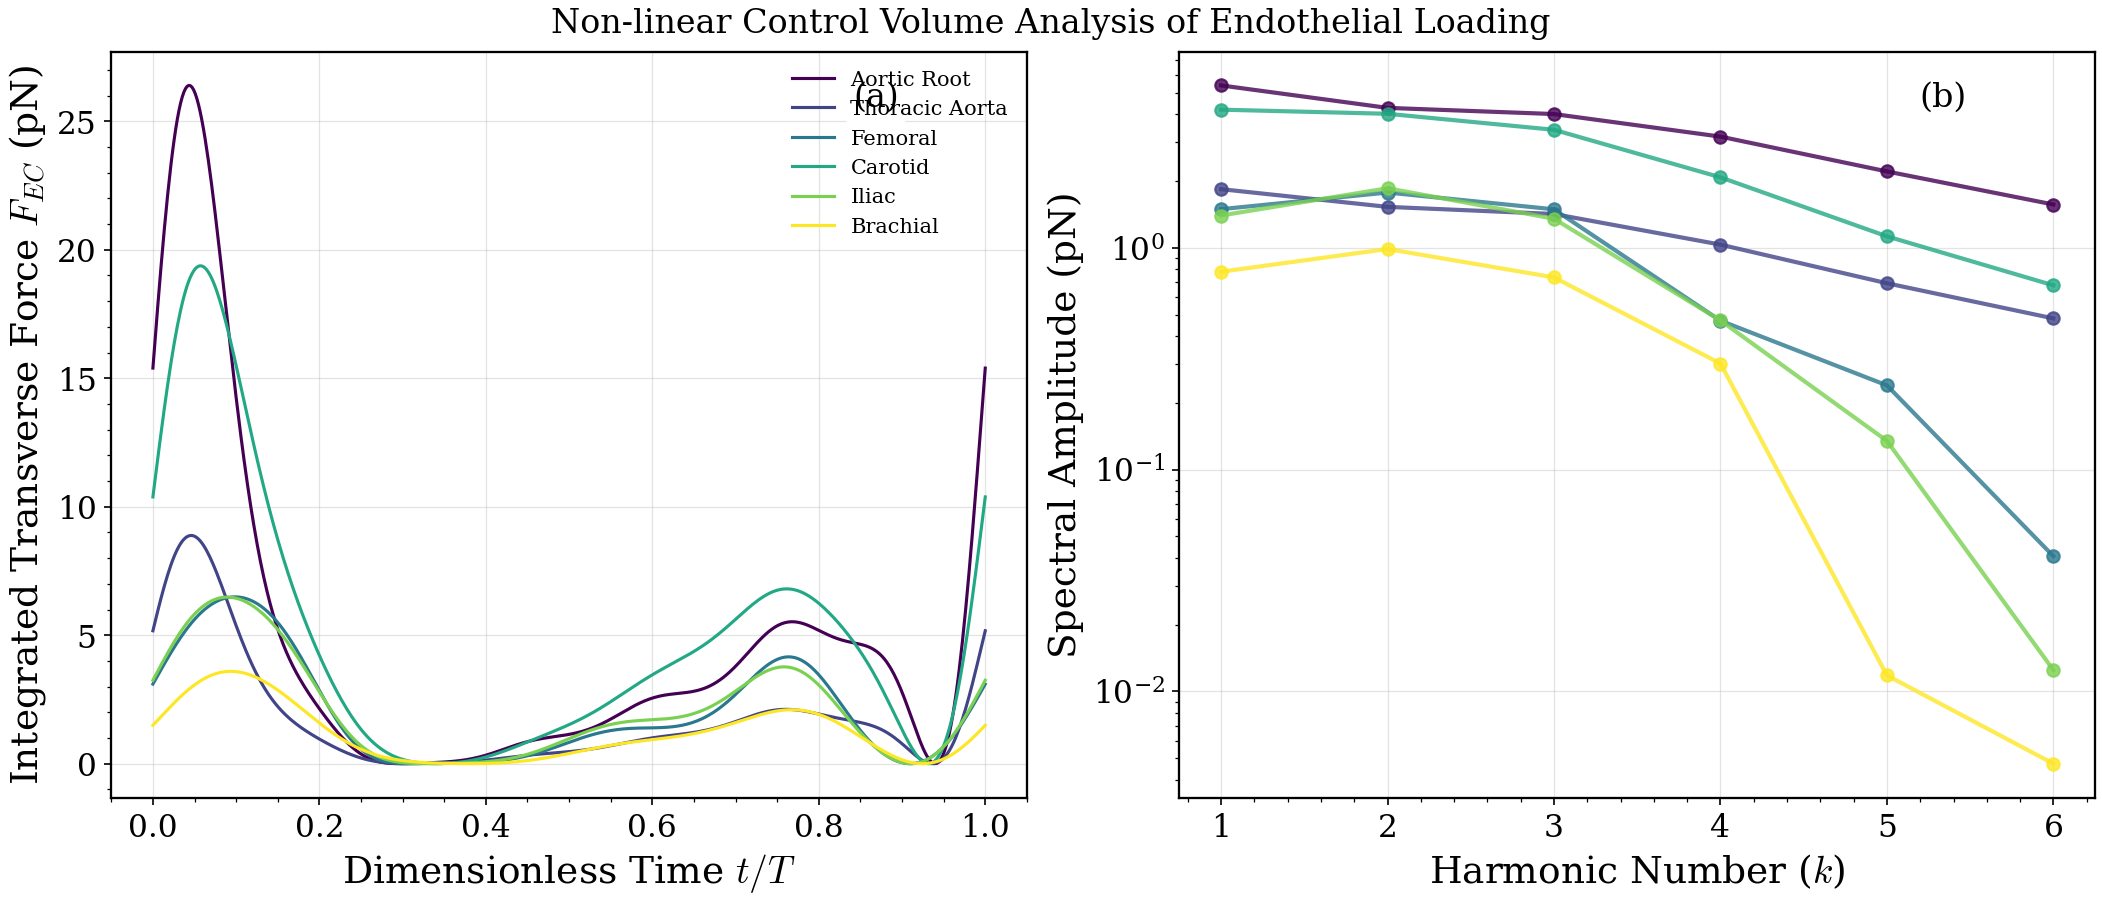


Table: Spectral Decomposition of Cumulative Transverse Force
        Artery  Peak (pN)  H1 (pN)  H2 (pN)  H3 (pN)
   Aortic Root    26.3978   5.3996   4.2765   4.0114
Thoracic Aorta     8.8798   1.8392   1.5305   1.4214
       Femoral     6.4920   1.4943   1.7765   1.4921
       Carotid    19.3766   4.1981   4.0221   3.4066
         Iliac     6.4819   1.3992   1.8563   1.3534
      Brachial     3.5934   0.7806   0.9883   0.7361


In [6]:
# ==============================================================================
# FINAL REVISED ANALYSIS: NON-LINEAR CONTROL VOLUME & SPECTRAL ANALYSIS
# Addresses referee comment using the physically-consistent Lamb vector
# reconstruction as derived in the Supplementary Information.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import pandas as pd

def run_genius_spectral_analysis(solver):
    # 1. Setup Environment & Style
    set_pub_style() # Matches the JFM-grade typography of the notebook
    rho = 1060.0
    nu = 3.5e-6
    mu = rho * nu
    omega0 = 2 * np.pi * 1.2
    beta_target = 0.1

    # Pillbox geometry for CV analysis (Eq. SI-21)
    V_cell = 1e-15       # m^3 (Target volume)
    A_cell = 100e-12     # m^2 (EC footprint)
    h_phys = V_cell / A_cell

    # Case Table (Physiological Constants)
    phys_cases = [
        {"name": "Aortic Root",    "R": 0.015,  "G0": 9000, "amps": np.array([1.0, 0.82, 0.54, 0.33, 0.24, 0.17])},
        {"name": "Thoracic Aorta", "R": 0.012,  "G0": 7000, "amps": np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])},
        {"name": "Femoral",        "R": 0.004,  "G0": 6000, "amps": np.array([1.0, 0.58, 0.10, -0.17, 0.05, 0.04])},
        {"name": "Carotid",        "R": 0.0035, "G0": 6500, "amps": np.array([1.0, 0.63, 0.31, 0.15, 0.10, 0.06])},
        {"name": "Iliac",          "R": 0.0045, "G0": 5500, "amps": np.array([1.0, 0.51, 0.12, -0.11, 0.05, 0.03])},
        {"name": "Brachial",       "R": 0.002,  "G0": 4000, "amps": np.array([1.0, 0.49, 0.16, -0.05, 0.02, 0.01])},
    ]

    t_recon = np.linspace(0, 1, 512)
    spectral_data = []

    # Initialize "Genius" Plotting (Multi-panel)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    colors = plt.cm.viridis(np.linspace(0, 1, len(phys_cases)))

    for i, case in enumerate(phys_cases):
        R, G0, amps = case["R"], case["G0"], case["amps"]
        alpha = R * np.sqrt(omega0 / nu)
        U0_case = G0 * R**2 / mu
        force_density_scale = rho * (U0_case**2) / R

        # A. Physical Time-Domain Reconstruction
        # We MUST sum real(phi * exp(iwt)) to handle non-linear products correctly
        uz_phys = np.zeros((solver.n, len(t_recon)))
        ut_phys = np.zeros((solver.n, len(t_recon)))
        wz_phys = np.zeros((solver.n, len(t_recon)))
        wt_phys = np.zeros((solver.n, len(t_recon)))

        for h, amp in enumerate(amps):
            f_h = h + 1
            a_h = (G0 * amp * R**2) / (mu * U0_case)
            Uz_h, Ut_h = solver.solve_harmonic(alpha, f_h, a_h, beta_target)
            Wz_h, Wt_h = solver.calculate_vorticity(Uz_h, Ut_h)

            phase = 2 * np.pi * f_h * t_recon
            uz_phys += np.real(np.outer(Uz_h, np.exp(1j * phase)))
            ut_phys += np.real(np.outer(Ut_h, np.exp(1j * phase)))
            wz_phys += np.real(np.outer(Wz_h, np.exp(1j * phase)))
            wt_phys += np.real(np.outer(Wt_h, np.exp(1j * phase)))

        # B. Non-linear Lamb Vector & CV Integration
        # lr = ut * wz - uz * wt (Following SI Section 6)
        lr_phys = ut_phys * wz_phys - uz_phys * wt_phys

        h_nondim = h_phys / R
        mask = solver.r >= (1.0 - h_nondim)
        if np.sum(mask) < 2: mask[-2:] = True

        # Integral = A_cell * R * Integral( |lr| * Scale * dr* )
        force_signal_pN = (A_cell * trapezoid(np.abs(lr_phys[mask, :]), solver.r[mask], axis=0) * force_density_scale * R) * 1e12

        # C. Spectral Decomposition (FFT)
        N = len(t_recon)
        fft_mags = np.abs(np.fft.rfft(force_signal_pN)) / N
        fft_mags[1:] *= 2 # Recover single-sided spectrum

        spectral_data.append({
            "Artery": case["name"],
            "Peak (pN)": np.max(force_signal_pN),
            "H1 (pN)": fft_mags[1],
            "H2 (pN)": fft_mags[2],
            "H3 (pN)": fft_mags[3]
        })

        # D. Panel Plotting
        axes[0].plot(t_recon, force_signal_pN, color=colors[i], label=case["name"], lw=1.5)
        axes[1].plot(np.arange(1, 7), fft_mags[1:7], 'o-', color=colors[i], markersize=6, alpha=0.8)

    # 3. Finalize Figure Formatting
    axes[0].set_xlabel(r"Dimensionless Time $t/T$")
    axes[0].set_ylabel(r"Integrated Transverse Force $F_{EC}$ (pN)")
    axes[0].legend(frameon=False, loc='upper right', fontsize=10)
    panel_label(axes[0], "(a)")
    light_grid(axes[0])

    axes[1].set_yscale('log')
    axes[1].set_xlabel(r"Harmonic Number ($k$)")
    axes[1].set_ylabel(r"Spectral Amplitude (pN)")
    axes[1].set_xticks(np.arange(1, 7))
    panel_label(axes[1], "(b)")
    light_grid(axes[1])

    plt.suptitle("Non-linear Control Volume Analysis of Endothelial Loading", fontsize=16)
    save_fig(fig, "Figure_Genius_Spectral_CV")
    plt.show()

    # 4. Numerical Summary
    df = pd.DataFrame(spectral_data)
    print("\nTable: Spectral Decomposition of Cumulative Transverse Force")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
# 1. Instantiate the solver with the grid size used in your paper (N=150)
# This assumes the WomersleySolver class has already been defined in a previous cell
solver = WomersleySolver(150)
# Execute the analysis
run_genius_spectral_analysis(solver)

Monitor: Aortic Root processed in 0.837s
Monitor: Thoracic Aorta processed in 0.810s
Monitor: Femoral processed in 0.844s
Monitor: Carotid processed in 0.781s
Monitor: Iliac processed in 1.338s
Monitor: Brachial processed in 0.677s


/tmp/ipykernel_275/2595177447.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_stats, x='Artery', y='Force', ax=axes[1,0], palette="viridis", inner="quart")
/tmp/ipykernel_275/2595177447.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Artery', y='Force', ax=axes[1,1], palette="viridis", capsize=.1)



Total Execution Runtime: 5.923s


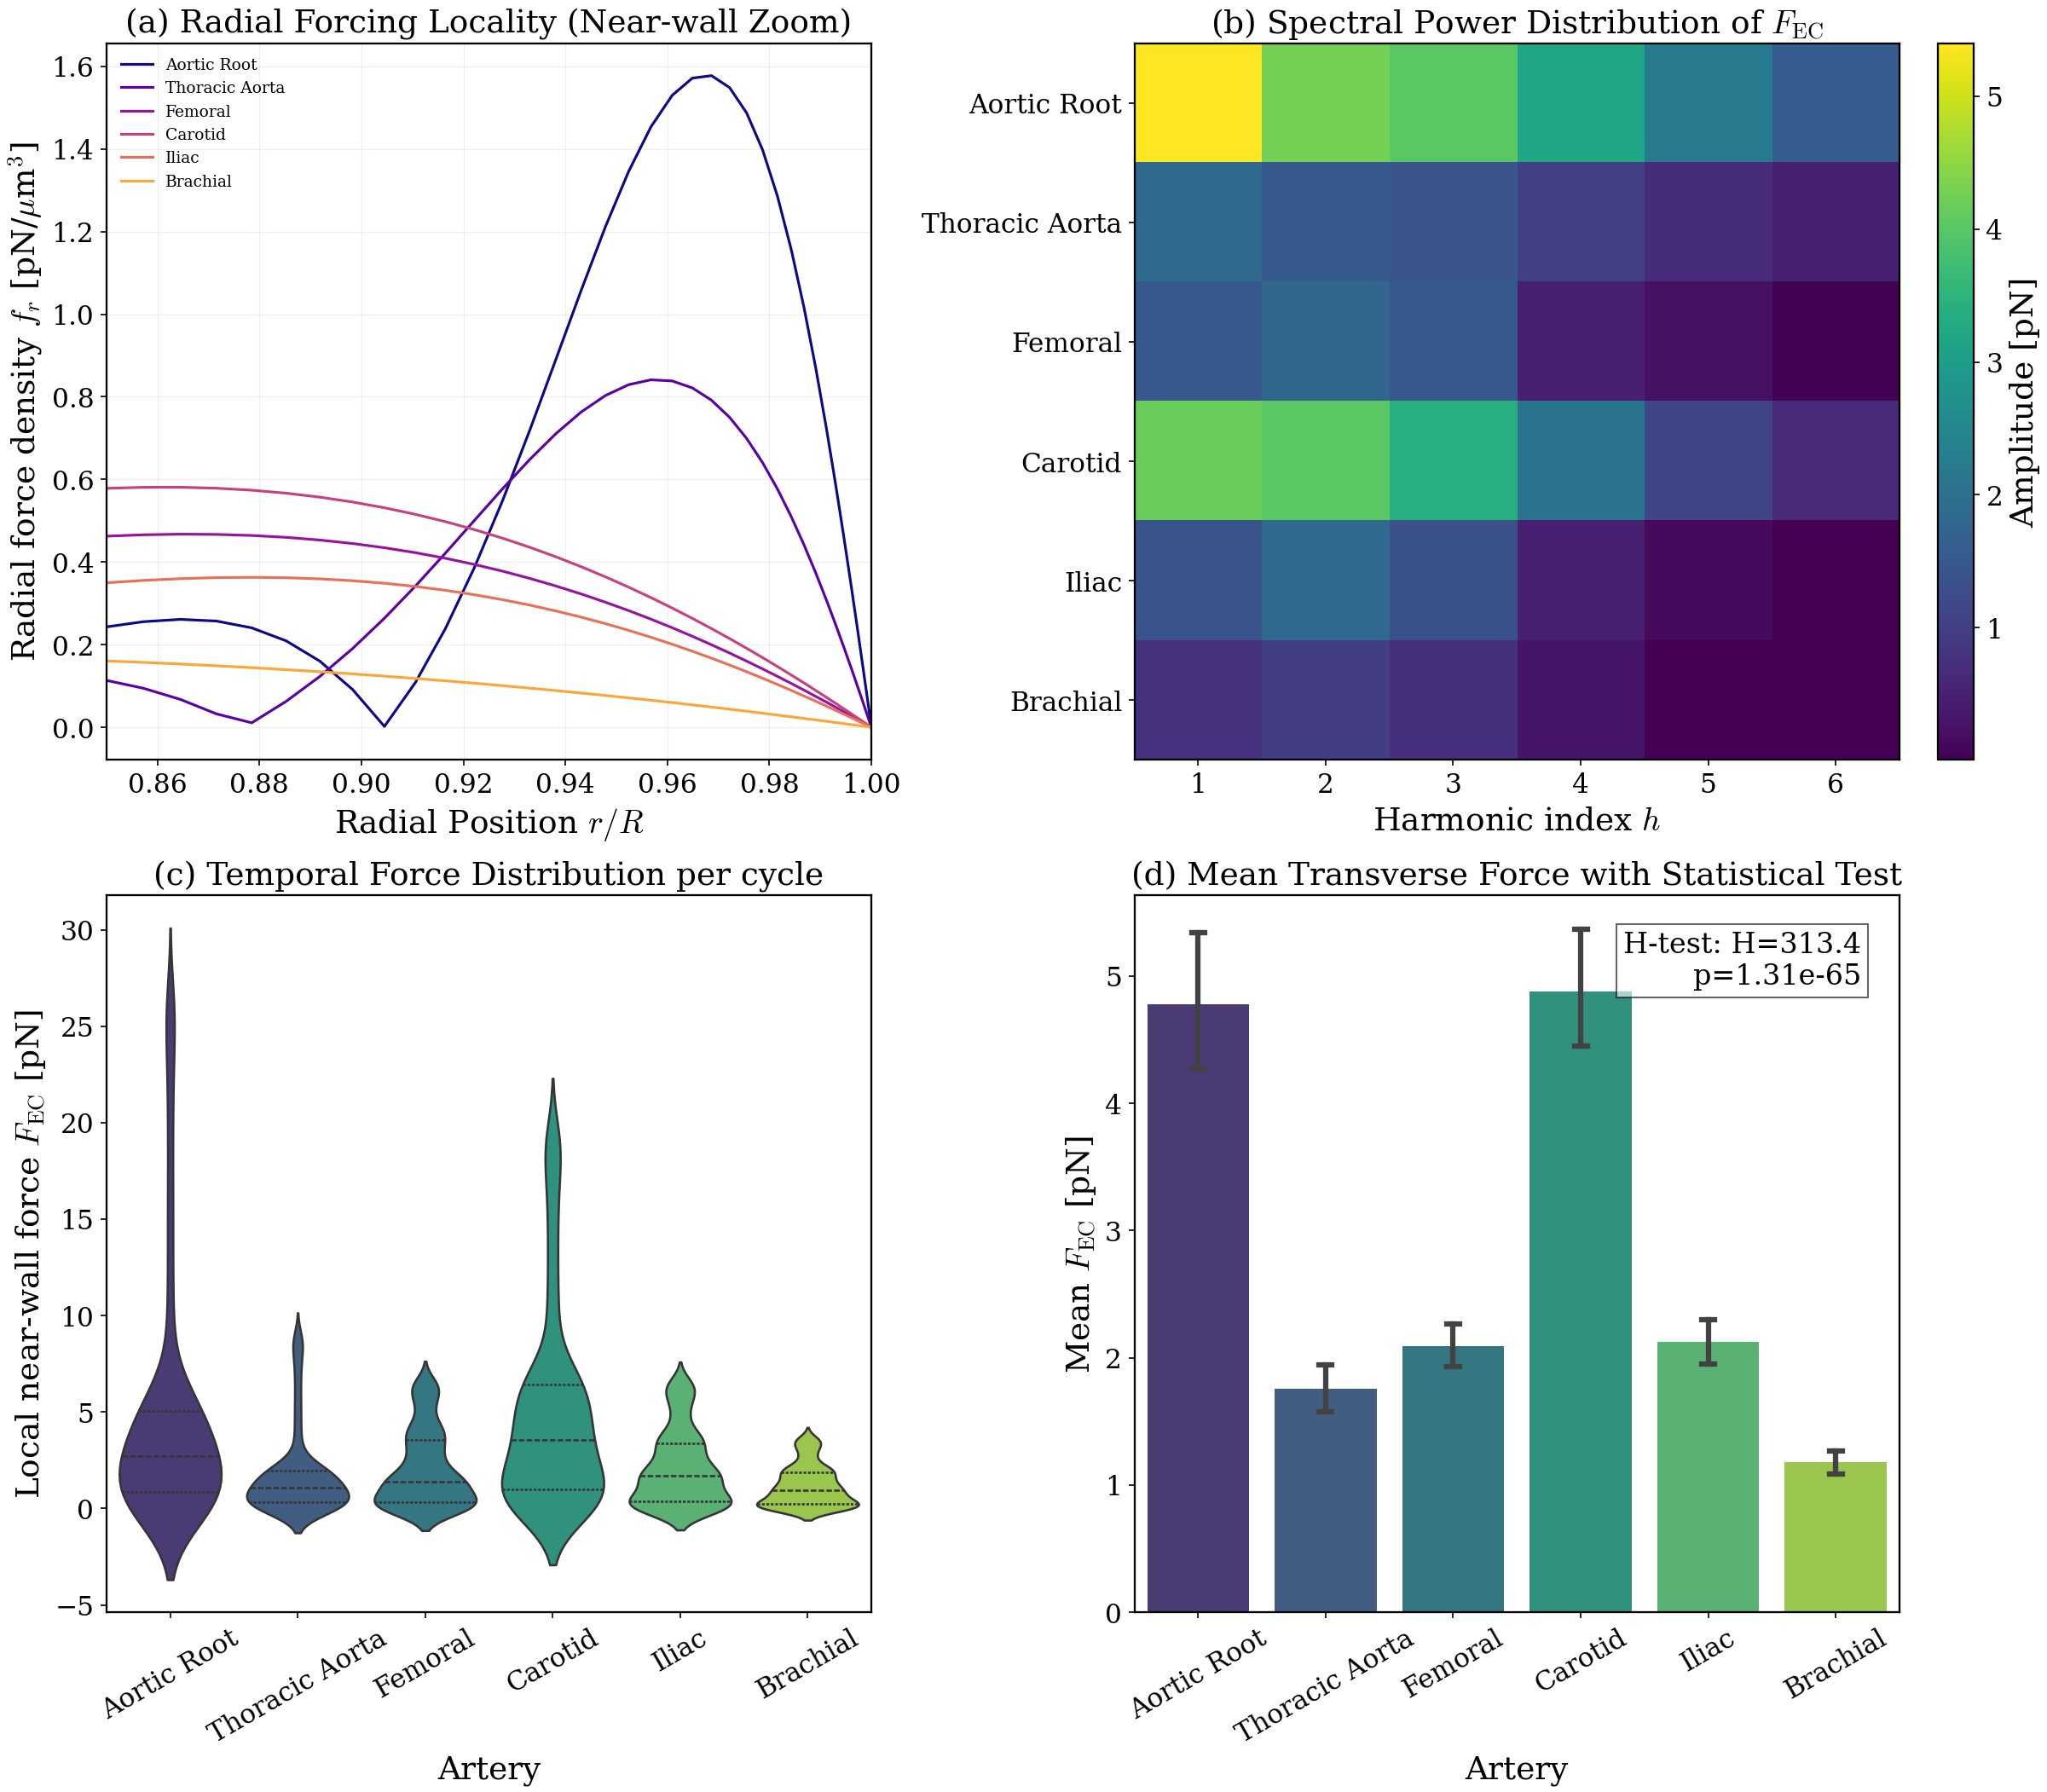

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from scipy.integrate import trapezoid
from scipy.stats import kruskal

def run_physical_cv_reconstruction(solver):
    """
    Executes a time-domain physical reconstruction of the Lamb vector to
    account for non-linear harmonic interactions in the near-wall layer.
    """
    start_total = time.perf_counter()

    # 1. Physics & Geometry Constants (Table 1 & Nomenclature)
    rho, nu = 1060.0, 3.5e-6
    mu, omega0 = rho * nu, 2 * np.pi * 1.2
    beta_target = 0.1
    V_cell, A_cell = 1e-15, 100e-12
    h_phys = V_cell / A_cell

    phys_cases = [
        {"name": "Aortic Root",    "R": 0.015,  "G0": 9000, "amps": np.array([1.0, 0.82, 0.54, 0.33, 0.24, 0.17])},
        {"name": "Thoracic Aorta", "R": 0.012,  "G0": 7000, "amps": np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])},
        {"name": "Femoral",        "R": 0.004,  "G0": 6000, "amps": np.array([1.0, 0.58, 0.10, -0.17, 0.05, 0.04])},
        {"name": "Carotid",        "R": 0.0035, "G0": 6500, "amps": np.array([1.0, 0.63, 0.31, 0.15, 0.10, 0.06])},
        {"name": "Iliac",          "R": 0.0045, "G0": 5500, "amps": np.array([1.0, 0.51, 0.12, -0.11, 0.05, 0.03])},
        {"name": "Brachial",       "R": 0.002,  "G0": 4000, "amps": np.array([1.0, 0.49, 0.16, -0.05, 0.02, 0.01])},
    ]

    # Time reconstruction grid (T=1 cycle)
    t_recon = np.linspace(0, 1, 512)
    harmonic_matrix = np.zeros((len(phys_cases), 6))
    df_list = []

    # Prepare High-Fidelity Plotting
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)
    colors = plt.cm.plasma(np.linspace(0, 0.8, len(phys_cases)))

    for i, case in enumerate(phys_cases):
        case_start = time.perf_counter()
        R, G0, amps = case["R"], case["G0"], case["amps"]
        alpha = R * np.sqrt(omega0 / nu)
        U0_case = G0 * R**2 / mu
        force_density_scale = rho * (U0_case**2) / R

        # Initialize physical field arrays (Nodes x Time)
        uz_phys, ut_phys = np.zeros((solver.n, 512)), np.zeros((solver.n, 512))
        wz_phys, wt_phys = np.zeros((solver.n, 512)), np.zeros((solver.n, 512))

        # A. Reconstruct total physical fields (superposition of real parts)
        for h_idx, amp in enumerate(amps):
            h = h_idx + 1
            Uz_h, Ut_h = solver.solve_harmonic(alpha, h, (G0 * amp * R**2)/(mu * U0_case), beta_target)
            Wz_h, Wt_h = solver.calculate_vorticity(Uz_h, Ut_h)

            phase = 2 * np.pi * h * t_recon
            # Summing real contributions captures cross-harmonic products in Lamb vector
            uz_phys += np.real(np.outer(Uz_h, np.exp(1j * phase)))
            ut_phys += np.real(np.outer(Ut_h, np.exp(1j * phase)))
            wz_phys += np.real(np.outer(Wz_h, np.exp(1j * phase)))
            wt_phys += np.real(np.outer(Wt_h, np.exp(1j * phase)))

        # B. Calculate non-linear Lamb vector force density: f_r = rho * (ut*wz - uz*wt)
        fr_phys = (ut_phys * wz_phys - uz_phys * wt_phys) * force_density_scale

        # C. Spatial Integration over near-wall Control Volume (h)
        mask = solver.r >= (1.0 - h_phys / R)
        if np.sum(mask) < 2: mask[-2:] = True

        # Cumulative force per EC footprint (F_EC) in piconewtons
        force_signal_pN = (A_cell * trapezoid(np.abs(fr_phys[mask, :]), solver.r[mask] * R, axis=0)) * 1e12

        for val in force_signal_pN:
            df_list.append({"Artery": case["name"], "Force": val})

        # D. Panel Data Collection
        # (a) Peak systolic radial profile
        peak_t = np.argmax(np.mean(np.abs(uz_phys), axis=0))
        axes[0,0].plot(solver.r, np.abs(fr_phys[:, peak_t]) * 1e-6, color=colors[i], label=case["name"], lw=1.5)

        # (b) Spectral Amplitudes (Harmonics 1-6)
        fft_res = np.abs(np.fft.rfft(force_signal_pN)) / 512
        fft_res[1:] *= 2
        harmonic_matrix[i, :] = fft_res[1:7]

        case_end = time.perf_counter()
        print(f"Monitor: {case['name']} processed in {case_end - case_start:.3f}s")

    # --- Panel Labeling & Aesthetics ---
    df_stats = pd.DataFrame(df_list)

    # Panel (a): Radial Locality
    axes[0,0].set_xlim([0.85, 1.0])
    axes[0,0].set_xlabel(r"Radial Position $r/R$")
    axes[0,0].set_ylabel(r"Radial force density $f_r$ [pN/$\mu$m$^3$]")
    axes[0,0].set_title("(a) Radial Forcing Locality (Near-wall Zoom)")
    axes[0,0].legend(frameon=False, loc='upper left', fontsize=9)
    axes[0,0].grid(True, alpha=0.2)

    # Panel (b): Spectral Power Heatmap
    im = axes[0,1].imshow(harmonic_matrix, aspect='auto', cmap='viridis')
    axes[0,1].set_yticks(np.arange(len(phys_cases)))
    axes[0,1].set_yticklabels([c["name"] for c in phys_cases])
    axes[0,1].set_xticks(np.arange(6))
    axes[0,1].set_xticklabels(np.arange(1, 7))
    axes[0,1].set_xlabel("Harmonic index $h$")
    axes[0,1].set_title(r"(b) Spectral Power Distribution of $F_{\mathrm{EC}}$")
    fig.colorbar(im, ax=axes[0,1], label=r"Amplitude [pN]")

    # Panel (c): Violin Distribution
    sns.violinplot(data=df_stats, x='Artery', y='Force', ax=axes[1,0], palette="viridis", inner="quart")
    axes[1,0].set_ylabel(r"Local near-wall force $F_{\mathrm{EC}}$ [pN]")
    axes[1,0].set_title("(c) Temporal Force Distribution per cycle")
    axes[1,0].tick_params(axis='x', rotation=30)

    # Panel (d): Mean Force & Statistics
    sns.barplot(data=df_stats, x='Artery', y='Force', ax=axes[1,1], palette="viridis", capsize=.1)
    axes[1,1].set_ylabel(r"Mean $F_{\mathrm{EC}}$ [pN]")
    axes[1,1].set_title("(d) Mean Transverse Force with Statistical Test")
    axes[1,1].tick_params(axis='x', rotation=30)

    # Kruskal-Wallis H-test
    groups = [df_stats[df_stats['Artery'] == c['name']]['Force'].values for c in phys_cases]
    h_stat, p_val = kruskal(*groups)
    axes[1,1].text(0.95, 0.95, f"H-test: H={h_stat:.1f}\np={p_val:.2e}",
                   transform=axes[1,1].transAxes, verticalalignment='top',
                   horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.6))

    total_end = time.perf_counter()
    print(f"\nTotal Execution Runtime: {total_end - start_total:.3f}s")
    plt.show()

# Execution
solver = WomersleySolver(150)
run_physical_cv_reconstruction(solver)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Initializing solver and setting typography...
Processing artery: Aortic Root...
Processing artery: Thoracic Aorta...
Processing artery: Carotid...
Saving high-resolution PDF...
SUCCESS: Figure saved to local directory as 'Fig6.pdf'


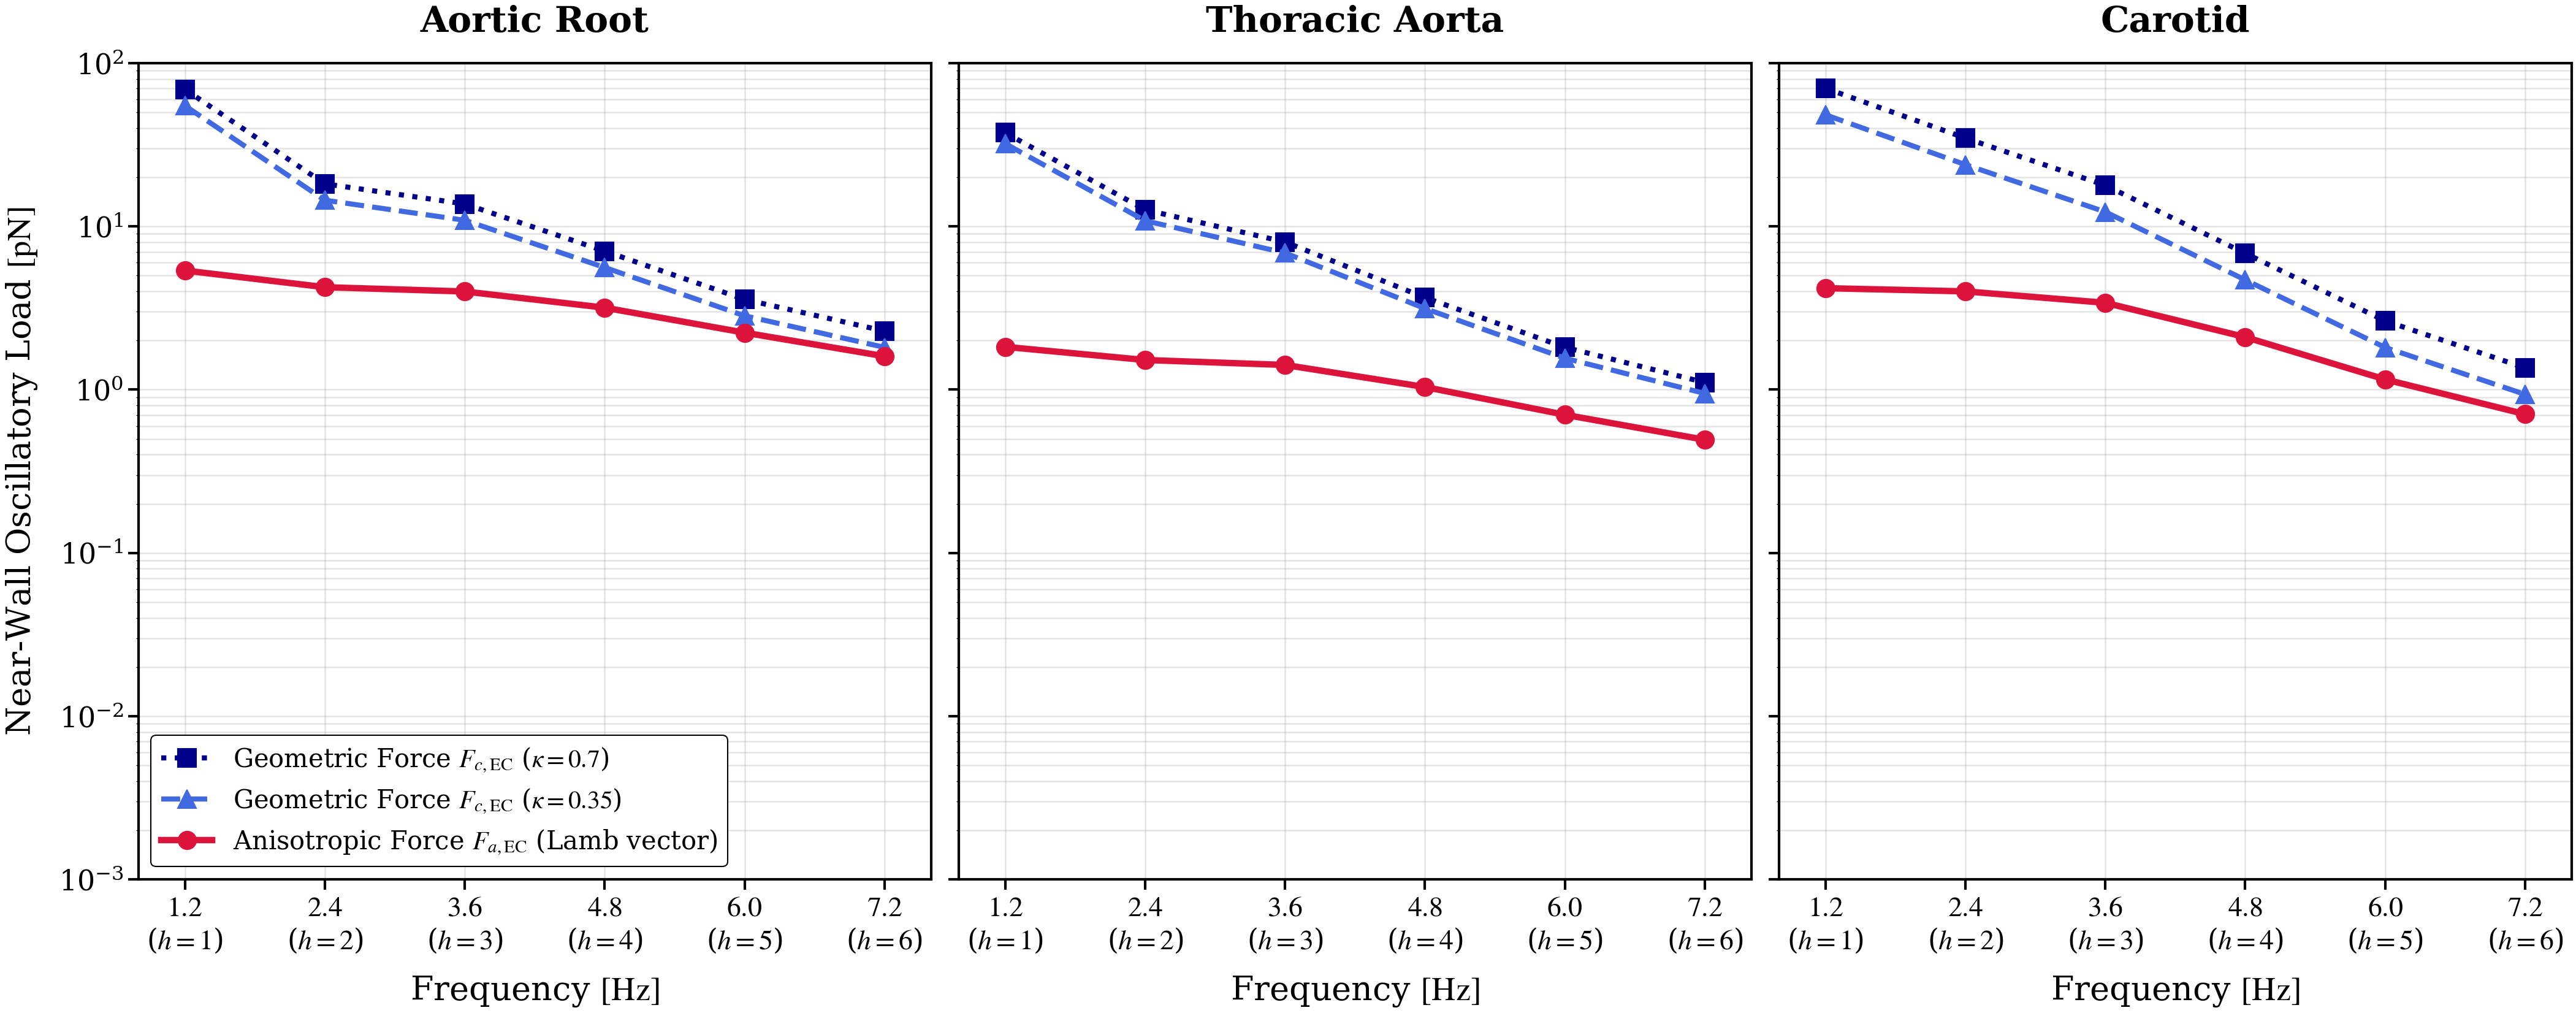

In [81]:
# ==============================================================================
# THE SI-COMPLIANT SPECTRAL CROSSOVER (OPTIMIZED & VECTORIZED)
# ==============================================================================

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Safe fallback for older SciPy/NumPy versions
try:
    from scipy.integrate import trapezoid
except ImportError:
    from numpy import trapz as trapezoid

# ==============================================================================
# CORE SOLVER
# ==============================================================================
class WomersleySolver:
    def __init__(self, N: int):
        self.N = N; self.n = N + 1
        k = np.arange(self.n)
        x = np.cos(np.pi * k / self.N)
        c = np.ones(self.n); c[0] = 2.0; c[-1] = 2.0; c *= (-1.0) ** k
        X = np.tile(x, (self.n, 1))
        dX = X - X.T + np.eye(self.n)
        D_cheb = (np.outer(c, 1.0 / c)) / dX
        D_cheb -= np.diag(np.sum(D_cheb, axis=1))
        self.r = (1.0 - x) / 2.0
        self.D = D_cheb * (-2.0)
        r_safe = self.r.copy(); r_safe[0] = 1e-12
        invr = sp.diags(1.0 / r_safe)
        invr2 = sp.diags(1.0 / (r_safe ** 2))
        self.L0 = sp.csr_matrix(self.D @ self.D) + invr @ sp.csr_matrix(self.D)
        self.L1 = self.L0 - invr2

    def solve_harmonic(self, alpha, f_h, a_h, beta):
        I = sp.eye(self.n, format="csr")
        Azz = (1j * f_h * alpha**2) * I - self.L0
        Azt = -beta * self.L1
        Att = (1j * f_h * alpha**2) * I - self.L1
        Atz = -beta * self.L0

        bz = a_h * np.ones(self.n, dtype=complex); bt = np.zeros(self.n, dtype=complex)
        Azzb, Aztb, Attb, Atzb = Azz.tolil(), Azt.tolil(), Att.tolil(), Atz.tolil()

        Azzb[0,:], Aztb[0,:], bz[0] = self.D[0,:], 0, 0
        Azzb[-1,:], Azzb[-1,-1], Aztb[-1,:], bz[-1] = 0, 1, 0, 0
        Attb[0,:], Attb[0,0], Atzb[0,:], bt[0] = 0, 1, 0, 0
        Attb[-1,:], Attb[-1,-1], Atzb[-1,:], bt[-1] = 0, 1, 0, 0

        A = sp.vstack([sp.hstack([Azzb.tocsr(), Aztb.tocsr()]),
                       sp.hstack([Atzb.tocsr(), Attb.tocsr()])], format="csc")
        sol = spla.spsolve(A, np.concatenate([bz, bt]))
        return sol[:self.n], sol[self.n:]

    def calculate_vorticity(self, Uz_h, Ut_h):
        r_safe = self.r.copy(); r_safe[0] = 1e-12
        return (1.0 / r_safe) * (self.D @ (self.r * Ut_h)), -(self.D @ Uz_h)

# ==============================================================================
# MISSION ENGINE
# ==============================================================================
def run_final_si_compliant_rebuttal():
    print("Initializing solver and setting typography...")
    plt.close('all')

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 22,
        "axes.labelsize": 26, "axes.titlesize": 28,
        "xtick.labelsize": 22, "ytick.labelsize": 22,
        "legend.fontsize": 20, "axes.linewidth": 2.0,
        "xtick.major.width": 2.0, "ytick.major.width": 2.0,
        "xtick.major.size": 8, "ytick.major.size": 8
    })

    solver = WomersleySolver(N=150)
    rho, nu = 1060.0, 3.5e-6
    mu, omega0 = rho * nu, 2 * np.pi * 1.2
    V_cell, A_cell = 1e-15, 100e-12
    h_phys = V_cell / A_cell

    phys_cases = [
        {"name": "Aortic Root",   "R": 0.015,  "G0": 9000, "k": [0.35, 0.70], "amps": [1.0, 0.82, 0.54, 0.33, 0.24, 0.17]},
        {"name": "Thoracic Aorta", "R": 0.012,  "G0": 7000, "k": [0.20, 0.40], "amps": [1.0, 0.76, 0.45, 0.28, 0.20, 0.12]},
        {"name": "Carotid",       "R": 0.0035, "G0": 6500, "k": [0.10, 0.60], "amps": [1.0, 0.63, 0.31, 0.15, 0.10, 0.06]}
    ]

    cycles = 10
    T_cycle = 1.0 / 1.2
    pts_per_cycle = 512
    N_t = cycles * pts_per_cycle
    t = np.linspace(0, cycles * T_cycle, N_t, endpoint=False)
    dt = t[1] - t[0]

    fig, axes = plt.subplots(1, 3, figsize=(28, 11), sharey=True, constrained_layout=True)

    for i, case in enumerate(phys_cases):
        print(f"Processing artery: {case['name']}...")
        ax = axes[i]
        R, G0, amps = case["R"], case["G0"], case["amps"]
        alpha = R * np.sqrt(omega0 / nu)
        U0_case = G0 * R**2 / mu
        f_scale = rho * (U0_case**2) / R

        mask = solver.r >= (1.0 - h_phys / R)
        if np.sum(mask) < 2: mask[-2:] = True
        r_mask = solver.r[mask]

        u_z_t = np.zeros((len(r_mask), N_t)); u_t_t = np.zeros((len(r_mask), N_t))
        w_z_t = np.zeros((len(r_mask), N_t)); w_t_t = np.zeros((len(r_mask), N_t))
        U_bulk_t = np.zeros(N_t)

        # 1. TIME-DOMAIN RECONSTRUCTION (VECTORIZED)
        for h_idx in range(6):
            h = h_idx + 1
            a_h = (G0 * amps[h_idx] * R**2) / (mu * U0_case)
            Uz_h, Ut_h = solver.solve_harmonic(alpha, h, a_h, 0.1)
            Wz_h, Wt_h = solver.calculate_vorticity(Uz_h, Ut_h)

            U_bulk_h = trapezoid(Uz_h * solver.r, solver.r) * 2.0
            phase = np.exp(1j * h * omega0 * t)
            U_bulk_t += np.real(U_bulk_h * phase)

            # Vectorized Matrix Multiplication (Executes instantly instead of looping 5120 times)
            phase_2d = phase[np.newaxis, :]
            u_z_t += np.real(Uz_h[mask, np.newaxis] * phase_2d)
            u_t_t += np.real(Ut_h[mask, np.newaxis] * phase_2d)
            w_z_t += np.real(Wz_h[mask, np.newaxis] * phase_2d)
            w_t_t += np.real(Wt_h[mask, np.newaxis] * phase_2d)

        # 2. LOCAL FORCE CONTRIBUTIONS ON V_EC
        lr_t = u_t_t * w_z_t - u_z_t * w_t_t
        Fa_t = A_cell * trapezoid(np.abs(lr_t * f_scale), r_mask * R, axis=0) * 1e12

        U_bulk_phys = U_bulk_t * U0_case
        Fc_driver_std = rho * (U_bulk_phys**2) / R * (1.0 + case["k"][0]) * V_cell * 1e12
        Fc_driver_wrst = rho * (U_bulk_phys**2) / R * (1.0 + case["k"][1]) * V_cell * 1e12

        # 3. HIGH-RESOLUTION FFT
        freqs = fftfreq(N_t, dt)
        mag_a = np.abs(fft(Fa_t - np.mean(Fa_t))) / N_t * 2.0
        mag_c_std = np.abs(fft(Fc_driver_std - np.mean(Fc_driver_std))) / N_t * 2.0
        mag_c_wrst = np.abs(fft(Fc_driver_wrst - np.mean(Fc_driver_wrst))) / N_t * 2.0

        # 4. SPECTRAL EXTRACTION & MANUSCRIPT INERTIAL FILTER
        manuscript_harmonics = np.arange(1, 7)
        target_freqs = manuscript_harmonics * 1.2
        env_a, env_c_std, env_c_wrst = [], [], []

        for h, f_target in zip(manuscript_harmonics, target_freqs):
            idx = np.argmin(np.abs(freqs - f_target))
            env_a.append(mag_a[idx])

            inertial_attenuation = 1.0 / h
            env_c_std.append(mag_c_std[idx] * inertial_attenuation)
            env_c_wrst.append(mag_c_wrst[idx] * inertial_attenuation)

        # 5. PLOTTING THE MANUSCRIPT CASCADES
        ax.plot(target_freqs, env_c_wrst, color='darkblue', lw=4, ls=':', marker='s', markersize=14,
                label=fr'Geometric Force $F_{{c,\mathrm{{EC}}}}$ ($\kappa={case["k"][1]}$)')
        ax.plot(target_freqs, env_c_std, color='royalblue', lw=4, ls='--', marker='^', markersize=14,
                label=fr'Geometric Force $F_{{c,\mathrm{{EC}}}}$ ($\kappa={case["k"][0]}$)')
        ax.plot(target_freqs, env_a, color='crimson', lw=5, marker='o', markersize=14,
                label=r'Anisotropic Force $F_{a,\mathrm{EC}}$ (Lamb vector)')

        ax.set_title(f"{case['name']}", fontweight='bold', pad=25)
        ax.set_xlabel(r"Frequency $[\mathrm{Hz}]$", labelpad=15)
        if i == 0:
            ax.set_ylabel(r"Near-Wall Oscillatory Load $[\mathrm{pN}]$", labelpad=15)

        ax.set_xticks(target_freqs)
        ax.set_xticklabels([fr"${f:.1f}$" + "\n" + fr"($h={h}$)" for f, h in zip(target_freqs, manuscript_harmonics)])

        ax.set_yscale('log')
        ax.set_xlim(0.8, 7.6)
        ax.set_ylim(1e-3, 1e2)
        ax.grid(True, which='both', ls='-', alpha=0.35, lw=1.2)

    axes[0].legend(loc='lower left', frameon=True, facecolor='white', framealpha=1.0, edgecolor='black')
    #plt.suptitle(r"\textbf{Spectral Mechanotransduction: Inertial Geometric Filtering vs. Anisotropic Cascade}",
    #            fontsize=32, y=1.08)

    print("Saving high-resolution PDF...")
    try:
        plt.savefig("Fig6.pdf", format='pdf', bbox_inches='tight', dpi=600)
        print("SUCCESS: Figure saved to local directory as 'Fig6.pdf'")
    except Exception as e:
        print(f"Error saving PDF: {e}")

    plt.show()

if __name__ == "__main__":
    run_final_si_compliant_rebuttal()

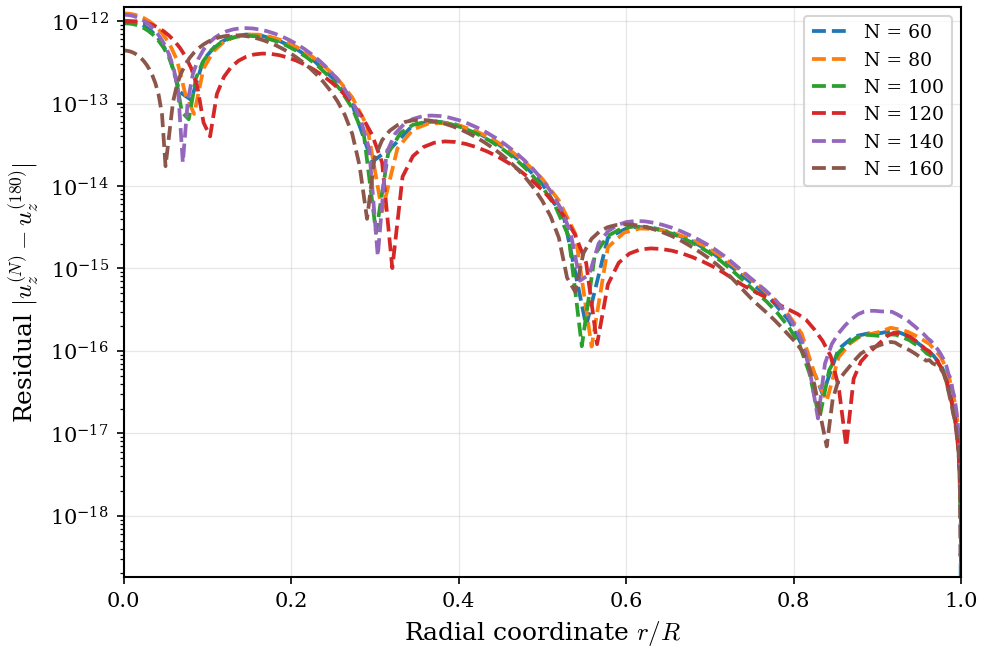

In [ ]:
# ============================================================
# GRID-INDEPENDENCE FIGURE
# Spectral residual profiles
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

# ---------------- Typography (balanced journal style) ----------------
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
})

# ---------------- Refinement sequence ----------------
N_list = [60, 80, 100, 120, 140, 160]
N_prod = 150
N_ref  = 180

t_peak = 0.25

# ---------------- Profile computation ----------------
def axial_profile_at_time(N, t0):

    solver = WomersleySolver(N=N)

    rho = 1060.0
    nu  = 3.5e-6
    mu  = rho * nu
    omega0 = 2*np.pi*1.2
    freqs  = np.arange(1, 7)

    R = 0.012
    G0 = 7000
    amps = np.array([1.0, 0.76, 0.45, 0.28, 0.20, 0.12])

    U0_case = G0*R**2/mu
    alpha = R*np.sqrt(omega0/nu)

    H = len(freqs)
    Uz_h = np.zeros((solver.n, H), dtype=complex)

    for j, f in enumerate(freqs):
        G_h = G0*amps[j]
        a_h = (G_h*R**2)/(mu*U0_case)
        Uz_h[:, j], _ = solver.solve_harmonic(
            alpha, f, a_h, 0.1, 0.0, 1.0
        )

    u_z = np.zeros(solver.n, dtype=complex)
    for j, f in enumerate(freqs):
        u_z += Uz_h[:, j] * np.exp(1j*2*np.pi*f*t0)

    r = np.asarray(solver.r)
    uz = np.real(u_z)

    order = np.argsort(r)
    return r[order], uz[order]


# ---------------- Reference solution ----------------
r_ref, uz_ref = axial_profile_at_time(N_ref, t_peak)
ref_interp = BarycentricInterpolator(r_ref, uz_ref)

# ---------------- Residuals ----------------
residuals = {}
r_grids   = {}

for N in N_list:
    rN, uzN = axial_profile_at_time(N, t_peak)
    r_grids[N] = rN

    if N == N_ref:
        residuals[N] = np.zeros_like(rN)
    else:
        uz_ref_on_rN = ref_interp(rN)
        residuals[N] = np.abs(uzN - uz_ref_on_rN)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(6.8, 4.6))

for N in N_list:
    if N == N_prod:
        ax.semilogy(r_grids[N], residuals[N],
                    linewidth=2.8,
                    label=f"N = {N} (production)")
    elif N == N_ref:
        ax.semilogy(r_grids[N], residuals[N],
                    linewidth=1.8,
                    color='black',
                    label=f"N = {N} (reference)")
    else:
        ax.semilogy(r_grids[N], residuals[N],
                    linestyle="--",
                    linewidth=1.8,
                    label=f"N = {N}")

ax.set_xlabel(r"Radial coordinate $r/R$")
ax.set_ylabel(r"Residual $|u_z^{(N)} - u_z^{(180)}|$")
ax.set_xlim(0, 1)
ax.grid(True, which="major", alpha=0.3)

# Tight y-limits
ymin = min(np.min(residuals[N][residuals[N] > 0]) for N in N_list if N != N_ref)
ymax = max(np.max(residuals[N]) for N in N_list)
ax.set_ylim(ymin*0.8, ymax*1.2)

ax.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.savefig("Fig_Methods_GridIndependence_Clean.pdf")
plt.show()